In [26]:
# ── 기본 데이터 처리 ──
import numpy as np
import pandas as pd

# ── 시각화 ──
import matplotlib.pyplot as plt
import seaborn as sns

# ── 전처리 · 피처 ──
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer

# ── 모델 ──
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor

# ── 평가 ──
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              mean_squared_error, mean_absolute_error, r2_score)

# ── 튜닝 ──
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# ── 모델 저장 ──
import joblib

In [27]:
SEED = 42
np.random.seed(SEED)

# sklearn 모델에 전달
# model = RandomForestClassifier(random_state=SEED)
# train_test_split(..., random_state=SEED)

In [28]:
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

In [29]:
import platform
# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [30]:
df = pd.read_csv('Courses.csv').drop(columns = 'index')

In [31]:
df.head()

,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,2013-11-17,NaN,9.0000,NaN,NaN,0,NaN,1.0000
1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaN,NaN,9.0000,NaN,1.0000,0,NaN,1.0000
2,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2013-02-08,2013-11-17,NaN,16.0000,NaN,NaN,0,NaN,1.0000
3,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-09-17,NaN,NaN,16.0000,NaN,NaN,0,NaN,1.0000
4,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,NaN,NaN,16.0000,NaN,NaN,0,NaN,1.0000


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 641138 entries, 0 to 641137
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   course_id          641138 non-null  str    
 1   userid_DI          641138 non-null  str    
 2   registered         641138 non-null  int64  
 3   viewed             641138 non-null  int64  
 4   explored           641138 non-null  int64  
 5   certified          641138 non-null  int64  
 6   final_cc_cname_DI  641138 non-null  str    
 7   LoE_DI             535130 non-null  str    
 8   YoB                544533 non-null  float64
 9   gender             554332 non-null  str    
 10  grade              592766 non-null  str    
 11  start_time_DI      641138 non-null  str    
 12  last_event_DI      462184 non-null  str    
 13  nevents            441987 non-null  float64
 14  ndays_act          478395 non-null  float64
 15  nplay_video        183608 non-null  float64
 16  nchapters    

In [33]:
df.describe()

,registered,viewed,explored,certified,YoB,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
count,641138.0000,641138.0000,641138.0000,641138.0000,544533.0000,441987.0000,478395.0000,183608.0000,382385.0000,641138.0000,0.0000,100161.0000
mean,1.0000,0.6243,0.0619,0.0276,1985.2533,431.0080,5.7103,114.8442,3.6344,0.0190,NaN,1.0000
std,0.0000,0.4843,0.2410,0.1638,8.8918,1516.1161,11.8665,426.9968,4.4910,0.2295,NaN,0.0000
min,1.0000,0.0000,0.0000,0.0000,1931.0000,1.0000,1.0000,1.0000,1.0000,0.0000,NaN,1.0000
25%,1.0000,0.0000,0.0000,0.0000,1982.0000,3.0000,1.0000,5.0000,1.0000,0.0000,NaN,1.0000
50%,1.0000,1.0000,0.0000,0.0000,1988.0000,24.0000,2.0000,18.0000,2.0000,0.0000,NaN,1.0000
75%,1.0000,1.0000,0.0000,0.0000,1991.0000,158.0000,4.0000,73.0000,4.0000,0.0000,NaN,1.0000
max,1.0000,1.0000,1.0000,1.0000,2013.0000,197757.0000,205.0000,98517.0000,48.0000,20.0000,NaN,1.0000


In [34]:
# 데이터 제거 1
df = df[~ ((df['viewed'] == 0) & (df['explored'] == 1))]
df = df[~ ((df['viewed'] == 1) & (df['explored'] == 0) & (df['certified'] == 1))]
len(df)

# 데이터 제거 2
df_complete = df[df['incomplete_flag'] != 1]
df = df_complete
len(df)

540282

분석 대상(last_event_DI가 Null인) 유저 수: 93,353명



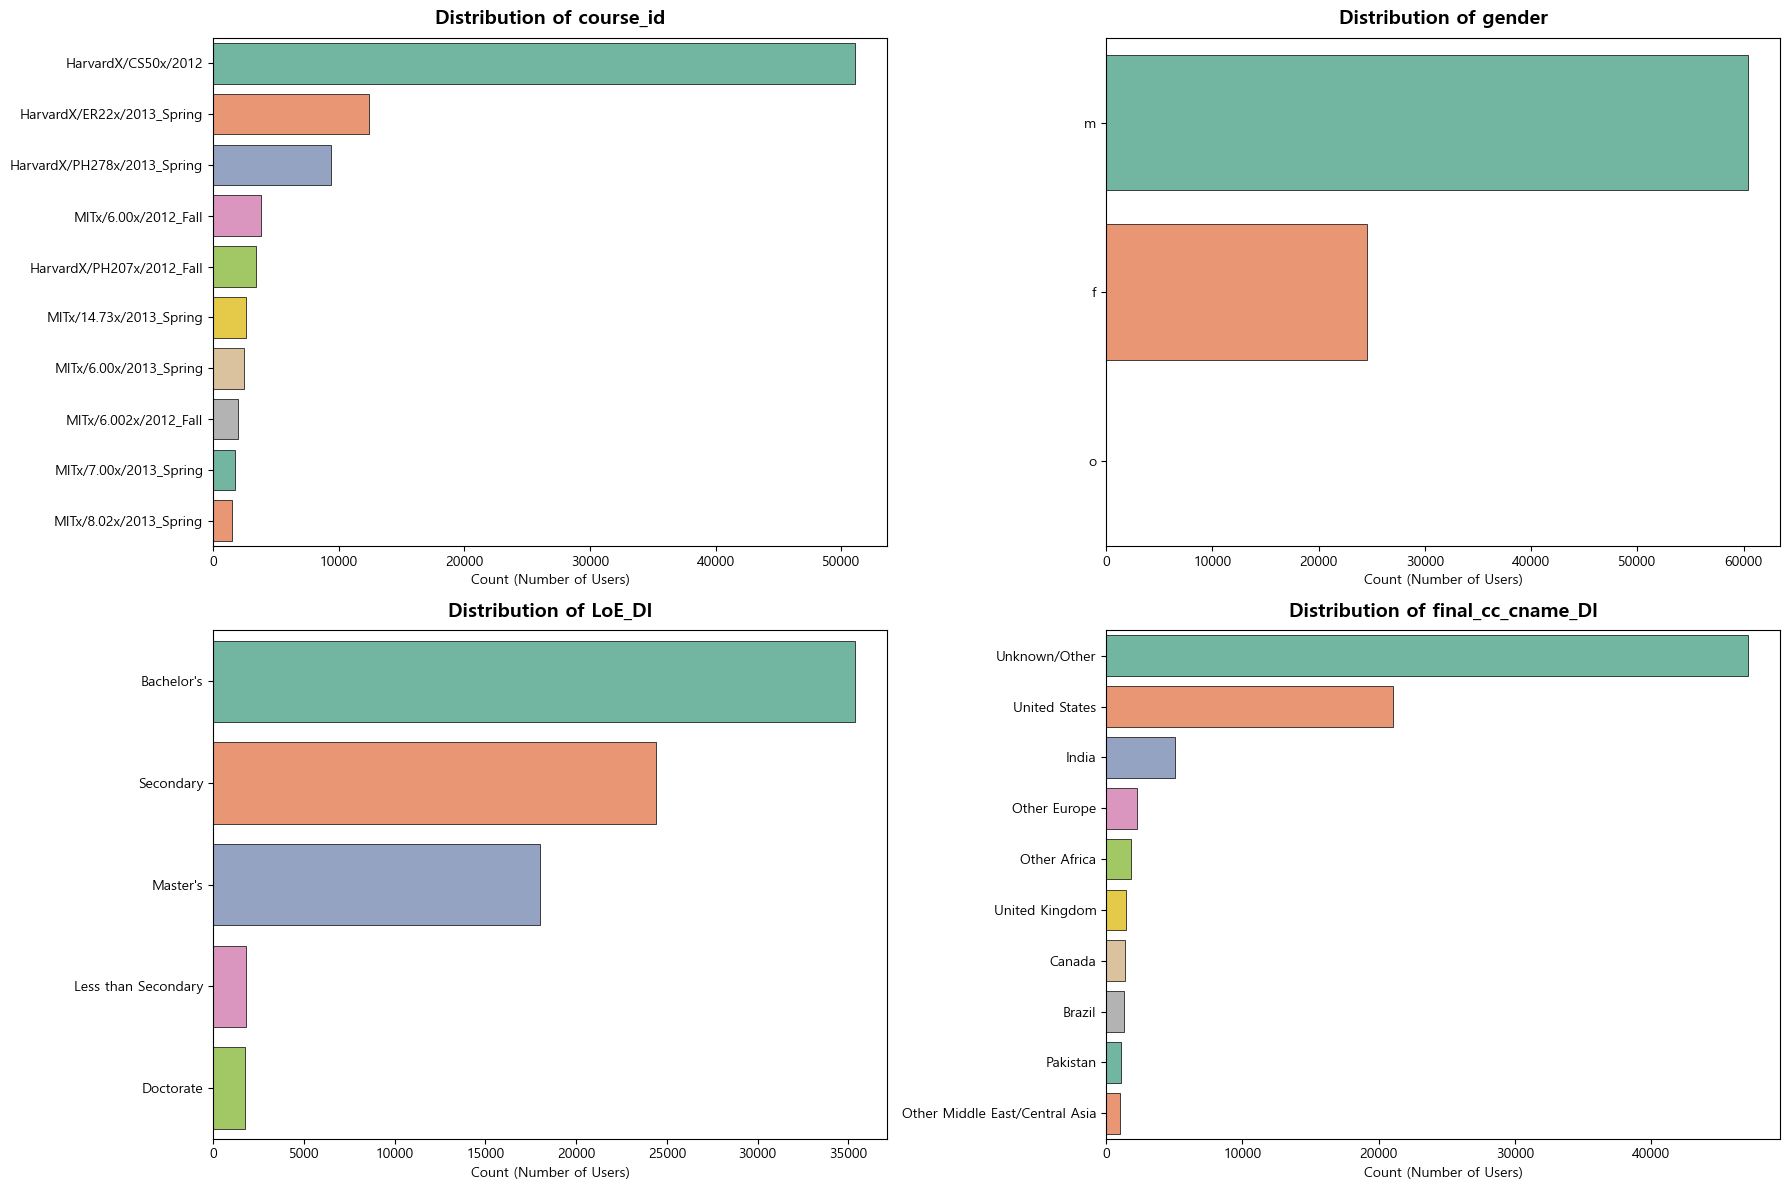

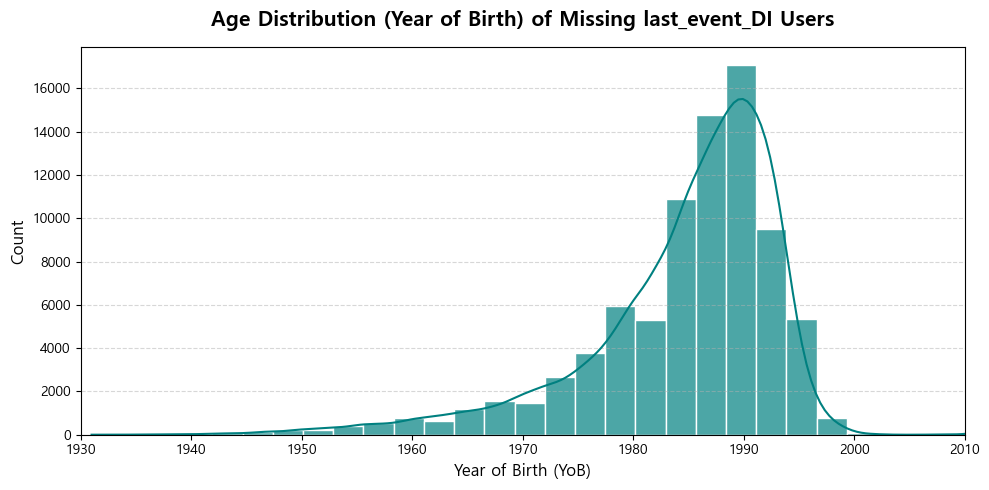

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 대체 처리 전, last_event_DI가 결측치(Null)인 유저만 쏙 뽑아내기!
null_users_df = df[df['last_event_DI'].isna()].copy()

print(f"분석 대상(last_event_DI가 Null인) 유저 수: {len(null_users_df):,}명\n")

# 2. 주요 범주형 수치 분석 (코스, 성별, 최종 학력, 국가)
cat_columns = ['course_id', 'gender', 'LoE_DI', 'final_cc_cname_DI']

# 2x2 사이즈 서브플롯(크게 4개의 그래프)을 준비합니다.
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for i, col in enumerate(cat_columns):
    row, col_idx = divmod(i, 2)
    
    # 보여줄 항목이 너무 많으면 지저분해지므로, 가장 많이 분포된 상위 10개만 추출
    top_values = null_users_df[col].value_counts().head(10).index
    
    # 상위 10개 항목의 데이터만 그립니다.
    sns.countplot(
        data=null_users_df[null_users_df[col].isin(top_values)], 
        y=col, 
        order=top_values, 
        palette='Set2', 
        ax=axes[row, col_idx],
        edgecolor='black',
        linewidth=0.5
    )
    axes[row, col_idx].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold', pad=10)
    axes[row, col_idx].set_xlabel('Count (Number of Users)')
    axes[row, col_idx].set_ylabel('')

plt.tight_layout()
plt.show()

# 3. 주요 수치형 변수(출생연도, YoB)를 통해 나이대 분포 확인
plt.figure(figsize=(10, 5))

# 출생연도가 없는 유저는 제외한 뒤, 히스토그램과 부드러운 선(KDE)을 같이 띄웁니다.
sns.histplot(null_users_df['YoB'].dropna(), bins=30, kde=True, color='teal', edgecolor='white', alpha=0.7)

plt.title('Age Distribution (Year of Birth) of Missing last_event_DI Users', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Year of Birth (YoB)', fontsize=12)
plt.ylabel('Count', fontsize=12)

# 가시성을 위해 극단적으로 과거에 태어난 데이터(이상치)들은 차트 양 끝에서 살짝 잘라줍니다.
plt.xlim(1930, 2010)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


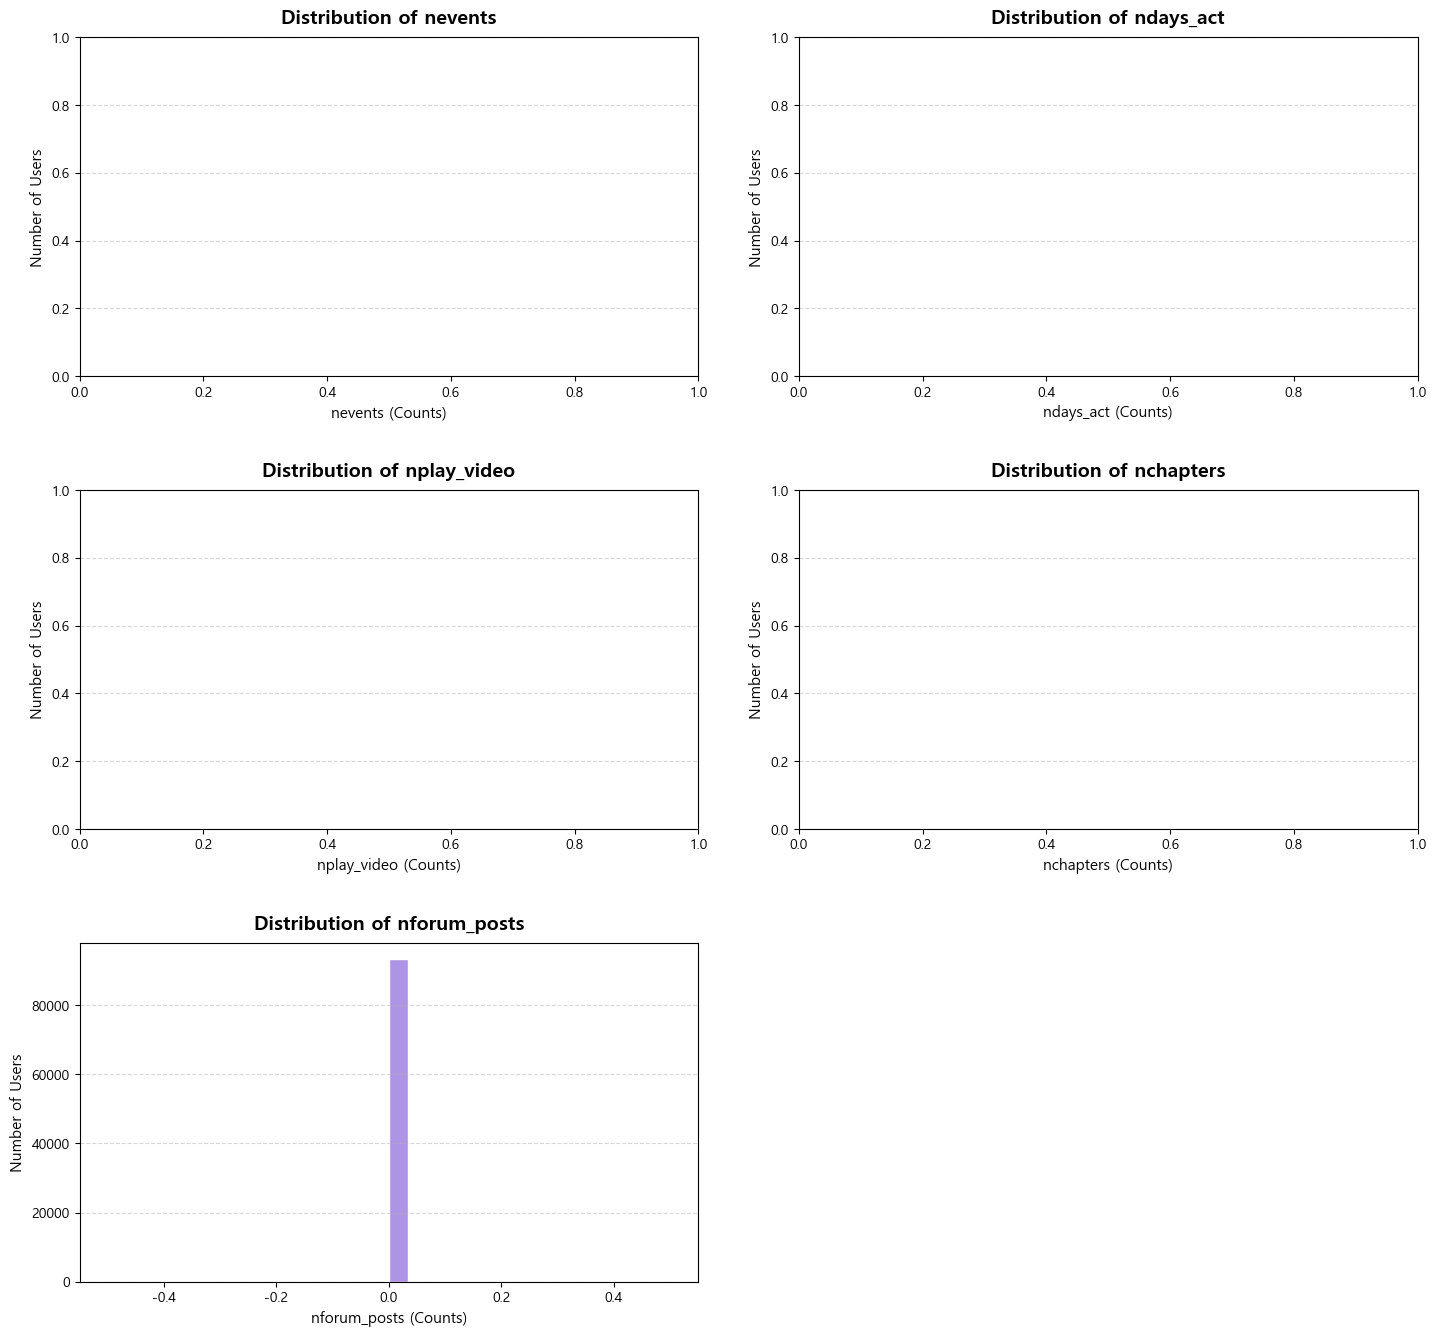

=== 활동 관련 수치 변수 요약 통계량 (last_event_DI = Null 인 그룹) ===


,nevents,ndays_act,nplay_video,nchapters,nforum_posts
count,0.0000,0.0000,0.0000,0.0000,93353.0000
mean,NaN,NaN,NaN,NaN,0.0000
std,NaN,NaN,NaN,NaN,0.0000
min,NaN,NaN,NaN,NaN,0.0000
25%,NaN,NaN,NaN,NaN,0.0000
50%,NaN,NaN,NaN,NaN,0.0000
75%,NaN,NaN,NaN,NaN,0.0000
max,NaN,NaN,NaN,NaN,0.0000


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 대체 처리 전, last_event_DI가 Null인 유저 추출
null_users_df = df[df['last_event_DI'].isna()].copy()

# 2. 활동 관련 수치형 변수 리스트
activity_cols = ['nevents', 'ndays_act', 'nplay_video', 'nchapters', 'nforum_posts']

# 3. 5개의 그래프를 담을 3행 2열(총 6칸)의 서브플롯 생성
fig, axes = plt.subplots(3, 2, figsize=(15, 14))

# 반복문을 쉽게 돌리기 위해 2차원 배열의 축(axes)을 1차원으로 쫙 폅니다.
axes = axes.flatten()

for i, col in enumerate(activity_cols):
    
    # 각 변수의 결측치를 제외한 실제 데이터 추출
    valid_data = null_users_df[col].dropna()
    
    # 히스토그램 그리기
    # 값들이 대부분 0이나 1과 같은 극소수에 몰려있을 확률이 매우 높습니다.
    sns.histplot(
        valid_data, 
        bins=30, 
        ax=axes[i], 
        color='mediumpurple', 
        edgecolor='white'
    )
    
    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel(f'{col} (Counts)', fontsize=11)
    axes[i].set_ylabel('Number of Users', fontsize=11)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    
    # 💡 팁: 특정 값(예: 0이나 1)에 수십만 명이 몰려있어 그래프의 형태를 보기 힘들다면, 
    # 아래 코드의 주석(#)을 풀어서 Y축을 로그 스케일로 변환해 보세요.
    # axes[i].set_yscale('log')

# 총 5개의 변수만 있으므로 마지막 6번째 남는 빈 그래프 영역은 깔끔하게 삭제
fig.delaxes(axes[5])

plt.tight_layout(pad=3.0)
plt.show()

# 4. 시각화 외에, 집단 내의 정확한 기초 통계량(평균, 최소값, 25/50/75% 분위수 등)을 확인합니다.
print("=== 활동 관련 수치 변수 요약 통계량 (last_event_DI = Null 인 그룹) ===")
display(null_users_df[activity_cols].describe())


In [37]:
# (참고) 먼저 날짜 데이터가 문자열(String)인 경우 datetime 객체로 변환해 주는 작업이 선행되어야 합니다.
df['start_time_DI'] = pd.to_datetime(df['start_time_DI'])
df['last_event_DI'] = pd.to_datetime(df['last_event_DI'])

# 1. last_event_DI 가 결측치(NaN/NaT)인 값을 찾아 start_time_DI 값으로 채워 넣습니다.
df['last_event_DI'] = df['last_event_DI'].fillna(df['start_time_DI'])

# 2. duration_days 컬럼을 생성합니다.
# dt.days 를 붙여주면 시간(Timedelta) 형식에서 순수 '일(Day)수' 부분만 정수형으로 뽑아냅니다.
df['duration_days'] = (df['last_event_DI'] - df['start_time_DI']).dt.days

# 확인 (출력)
print("결측치가 잘 대체되고 duration_days가 계산되었는지 확인:")
df[['start_time_DI', 'last_event_DI', 'duration_days']].head(10)


결측치가 잘 대체되고 duration_days가 계산되었는지 확인:


,start_time_DI,last_event_DI,duration_days
5,2012-09-17,2013-05-23,248
7,2013-01-01,2013-05-14,133
8,2013-02-18,2013-03-17,27
10,2013-02-23,2013-06-14,111
11,2013-06-17,2013-06-17,0
12,2013-01-24,2013-08-03,191
14,2012-12-19,2013-08-17,241
15,2012-07-26,2013-01-16,174
16,2013-07-30,2013-08-27,28
18,2012-10-25,2012-12-04,40


In [38]:
# duration_days가 0인 유저의 총 인원수 확인
zero_duration_count = (df['duration_days'] == 0).sum()
print(f"당일 이탈(0일 생존) 유저 수: {zero_duration_count}명")
# 생존 일수별로 몇 명이 있는지 내림차순(가장 많은 순)으로 정렬하여 상위 10개 출력
print(df['duration_days'].value_counts().head(10))
# last_event_DI 컬럼의 빈값(NaN) 개수 확인
null_count = df['last_event_DI'].isna().sum()
print(f"last_event_DI 데이터가 없는 유저 수: {null_count}명")


당일 이탈(0일 생존) 유저 수: 236044명
duration_days
0     236044
1      35518
2       7443
3       5321
4       4507
5       4054
6       4031
7       3969
8       3421
14      3022
Name: count, dtype: int64
last_event_DI 데이터가 없는 유저 수: 0명


In [40]:
# 등록일(start_time_DI)의 '연도(year)'에서 출생연도(YoB)를 빼서 나이 계산
df['Age'] = df['start_time_DI'].dt.year - df['YoB']

# 확인
df[['start_time_DI', 'YoB', 'Age']]

,start_time_DI,YoB,Age
5,2012-09-17,NaN,NaN
7,2013-01-01,NaN,NaN
8,2013-02-18,NaN,NaN
10,2013-02-23,NaN,NaN
11,2013-06-17,NaN,NaN
...,...,...,...
641132,2013-09-07,1989.0000,24.0000
641133,2013-09-07,1991.0000,22.0000
641134,2013-09-07,1991.0000,22.0000
641135,2013-09-07,1979.0000,34.0000
